In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset.h5ad')
adata

Only considering the two last: ['.ruiz_sussman_prior_subset', '.h5ad'].
Only considering the two last: ['.ruiz_sussman_prior_subset', '.h5ad'].


AnnData object with n_obs × n_vars = 104 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'leiden', 'leiden_R', 'neighbors', 'tsne', 'umap'
    obsm: 'X_all_3d_phate', 'X_tsne', 'X_umap'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

In [ ]:
import glasbey

# Create a categorical palette with 15 colours
colors = glasbey.create_palette(palette_size=104)

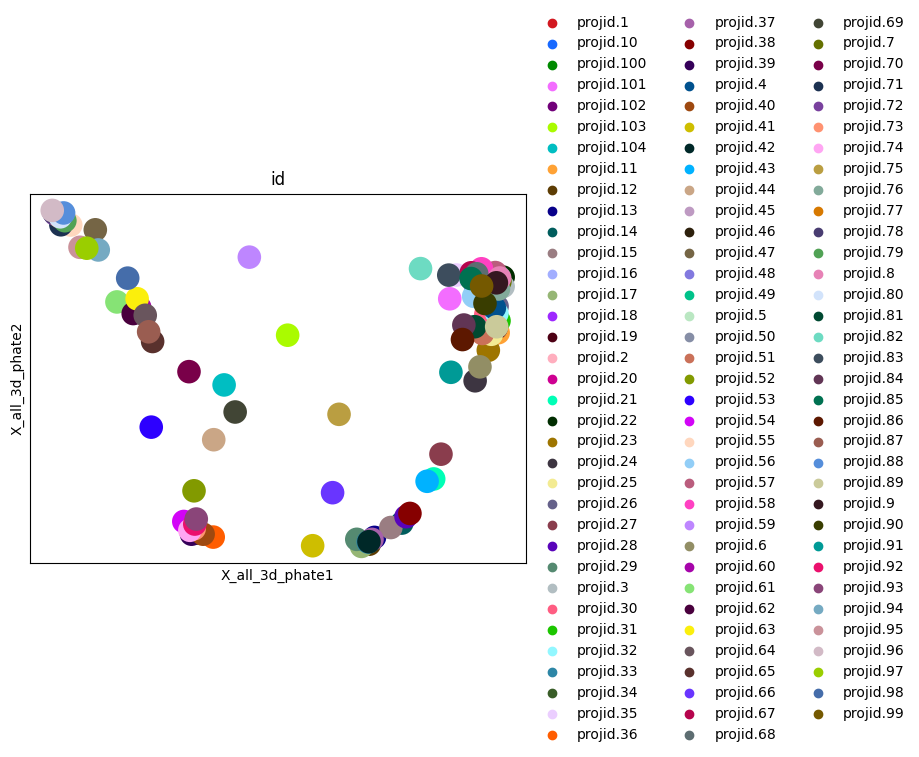

In [ ]:
adata.obs['id'] = pd.Categorical(adata.obs_names.to_list())
sc.pl.embedding(adata, 'X_all_3d_phate', color =['id'], palette=colors,save='figures/donor_embedding_Ruiz_Sussman.pdf')

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


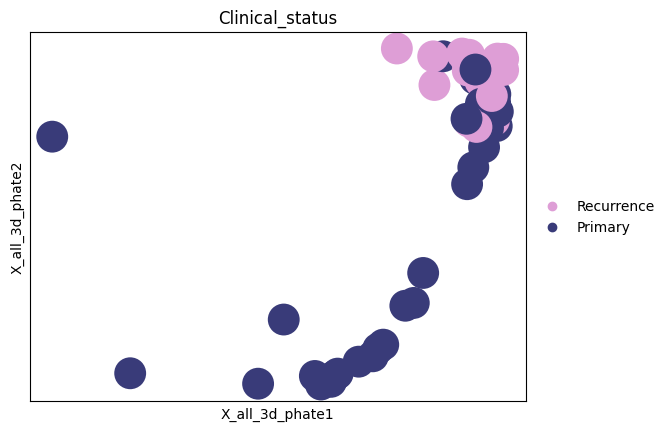

In [ ]:
sc.pl.embedding(adata[adata.obs['Tumor_type'].isin(['DMG H3 K27-altered'])], 'X_all_3d_phate', color =['Clinical_status'], palette=[ '#de9ed6','#393b79',], save='clinical_status_dmg.pdf')

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


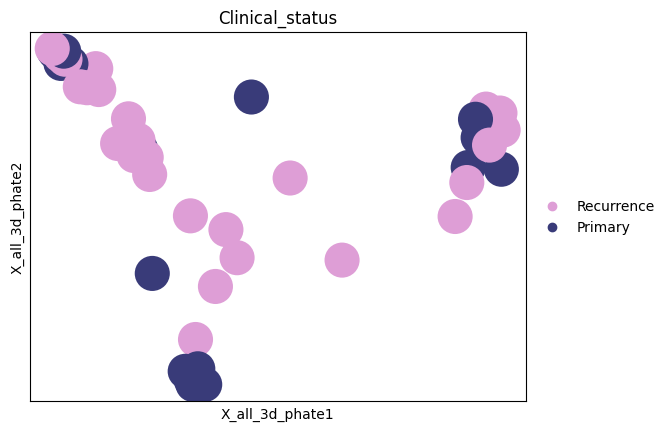

In [ ]:
sc.pl.embedding(adata[adata.obs['Tumor_type'].isin(['DpHGG H3-wt and IDH-wt'])], 'X_all_3d_phate', color =['Clinical_status'], palette=[ '#de9ed6','#393b79',], save='clinical_status_dg_h3w')

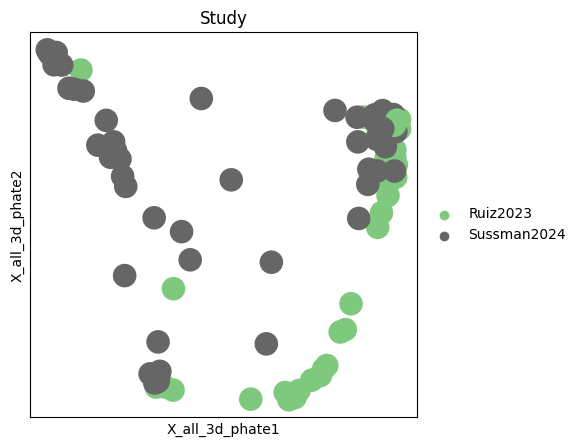

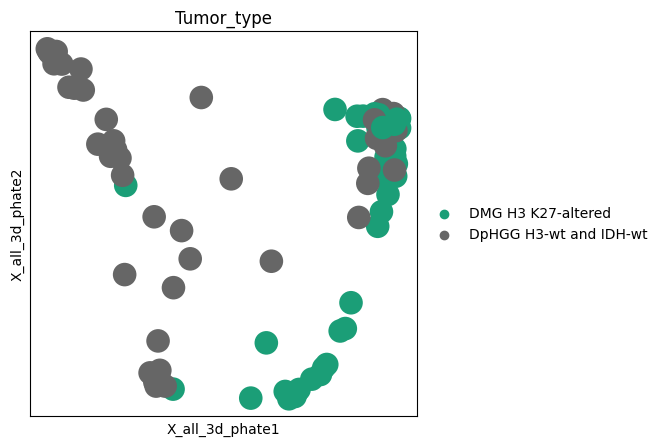

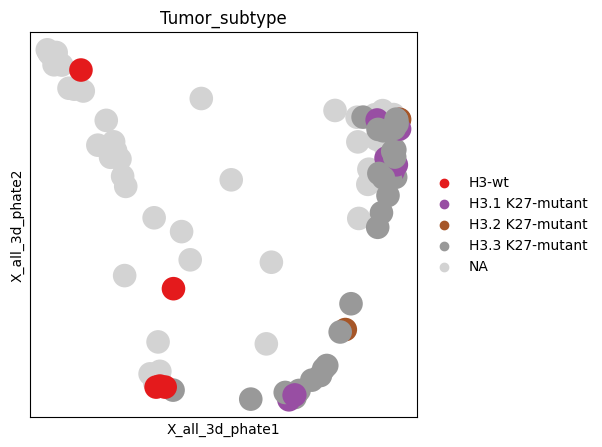

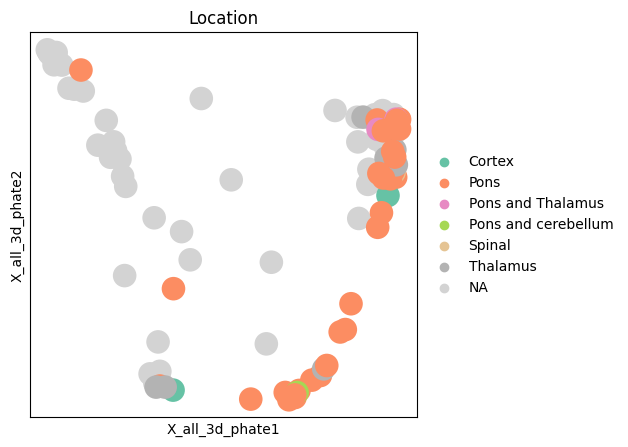

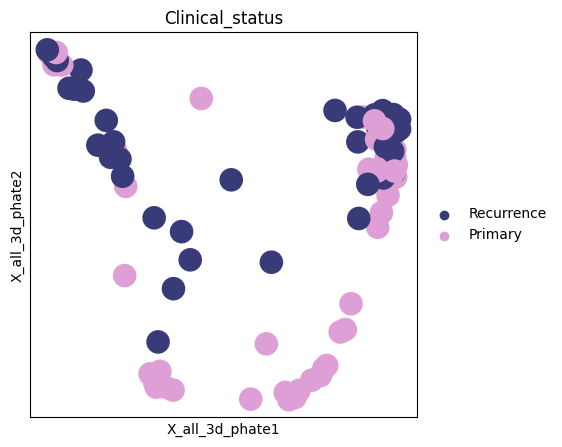

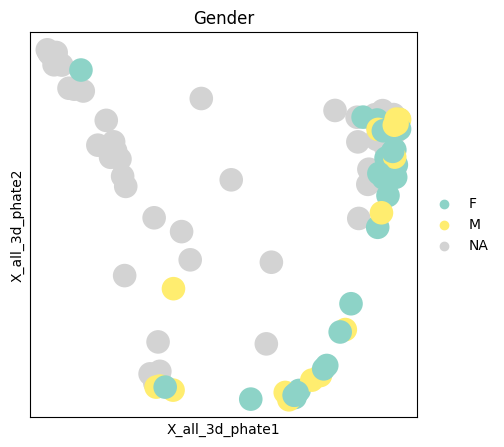

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib

# Predefined list of palettes
palettes = ['Accent', 'Dark2',
                      'Set1', 'Set2','tab20b', 'Set3', ]

# Get all categorical columns in adata.obs
categorical_columns = ['Study', 'Tumor_type', 'Tumor_subtype', 'Location', 'Clinical_status',  'Gender']

# Set default figure size globally
plt.rcParams["figure.figsize"] = (5, 5)
# Loop through each categorical column
for i, col in enumerate(categorical_columns):
    # Plot the embedding
    sc.pl.embedding(adata, 'X_all_3d_phate', color=[col], 
                    palette=palettes[i],show=True)
    
    # Save the plot
    # plt.savefig(f"figures/{col}_embedding_{palette_name}.pdf")
    plt.close()

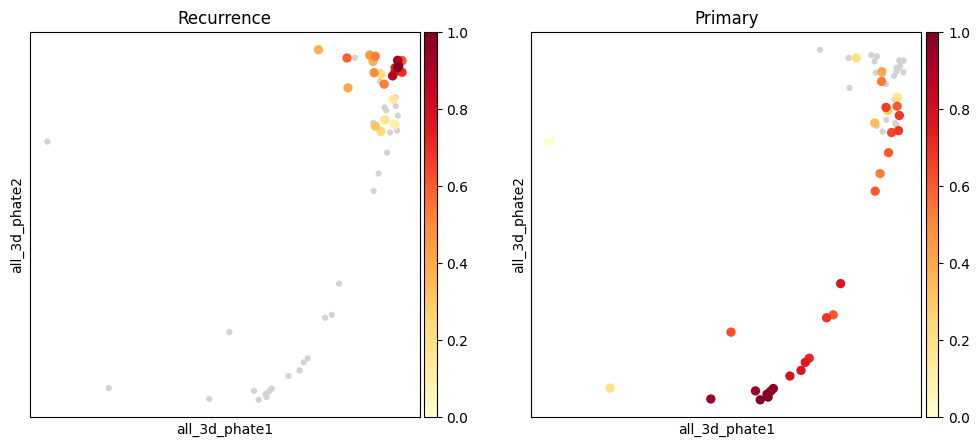

In [ ]:
# adata_filtered = adata[adata.obs['Tumor_type'] == 'DMG H3 K27-altered']
sc.tl.embedding_density(adata_filtered, groupby="Clinical_status",basis='all_3d_phate',)
sc.pl.embedding_density(adata_filtered, groupby="Clinical_status",basis='all_3d_phate',)

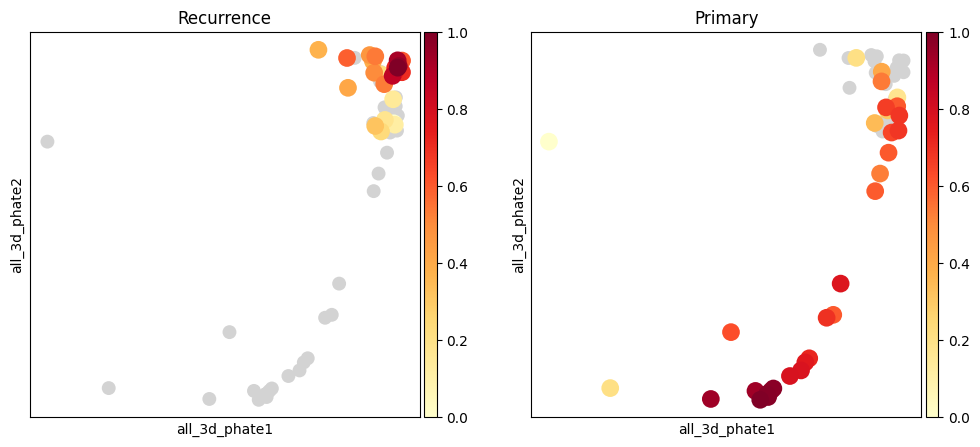

In [ ]:
import os
import scanpy as sc

save_path = "figures/umap_density_Clinical_status_figures"
file_name = "density_plot_beyond_DMG_only.pdf"

os.makedirs(save_path, exist_ok=True)

sc.pl.embedding_density(
    adata_filtered,
    groupby="Clinical_status",
    basis="all_3d_phate",
    bg_dotsize=400, fg_dotsize=650,
    save=os.path.join(file_name)
)

In [ ]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad')
adata

Only considering the two last: ['.ruiz_sussman_prior_subset_DMG', '.h5ad'].
Only considering the two last: ['.ruiz_sussman_prior_subset_DMG', '.h5ad'].


AnnData object with n_obs × n_vars = 57 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type', 'community', 'sub.community'
    uns: 'cell.types', 'communities', 'leiden', 'leiden_R', 'neighbors', 'ss.cor', 'trajectories', 'tsne', 'umap'
    obsm: 'X_all_3d_phate', 'X_phate', 'X_tsne', 'X_umap', 'communities', 'sub.communities'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

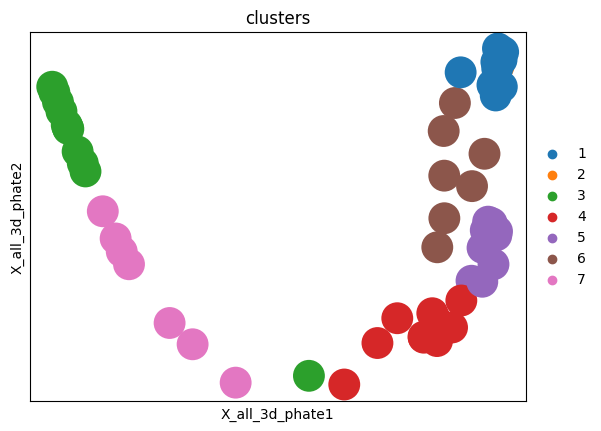

In [ ]:
sc.pl.embedding(adata, 'X_all_3d_phate', color =['clusters'])

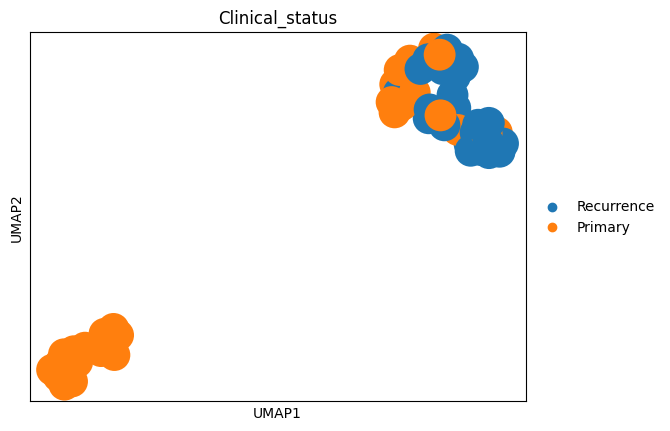

In [ ]:
sc.pl.umap(adata, color=['Clinical_status'])

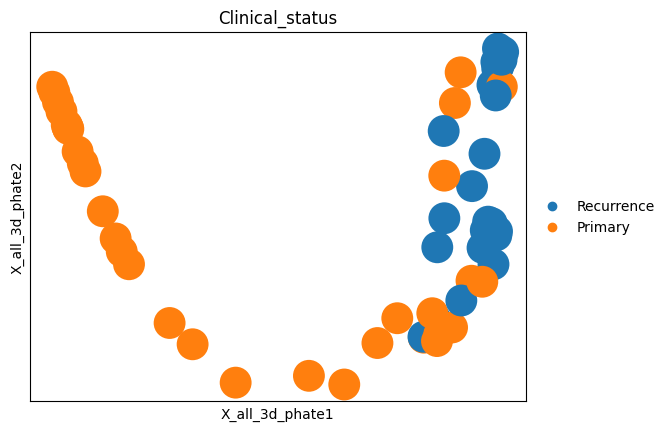

In [ ]:
sc.pl.embedding(adata, 'X_all_3d_phate', color =['Clinical_status'])

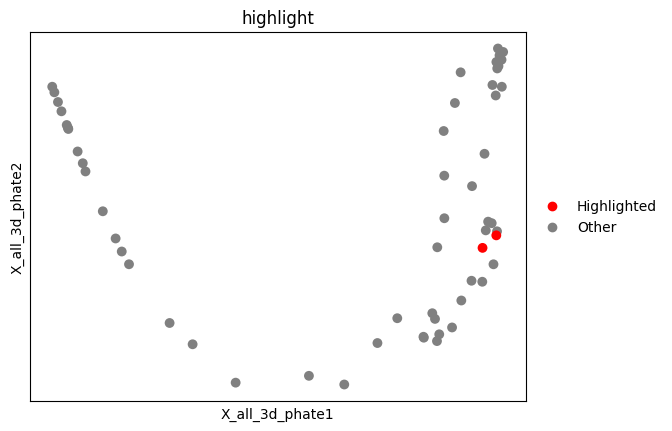

In [ ]:
# Create a new column in `adata.obs` to flag the two specific cells
adata.obs['highlight'] = np.where(adata.obs_names.isin(['projid.68', 'projid.82']), 'Highlighted', 'Other')

# Plot the embedding with custom colors
sc.pl.embedding(adata, 'X_all_3d_phate', color='highlight', size=200, palette={'Highlighted': 'red', 'Other': 'gray'})

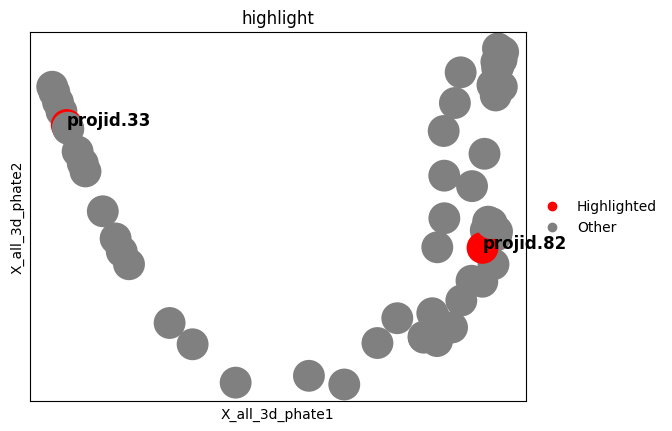

In [ ]:
# Plot the embedding with custom colors
ax = sc.pl.embedding(adata, 'X_all_3d_phate', color='highlight', palette={'Highlighted': 'red', 'Other': 'gray'}, show=False)

# Add labels for the specific cells
for cell_name in ['projid.33', 'projid.82']:
    cell_index = np.where(adata.obs_names == cell_name)[0][0]  # Get the index of the cell
    x, y = adata.obsm['X_all_3d_phate'][cell_index, :2]  # Get the coordinates of the cell
    ax.text(x, y, cell_name, color='black', fontsize=12, fontweight='bold')  # Add label

plt.show()

In [ ]:
adata

AnnData object with n_obs × n_vars = 57 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters', 'all_3d_phate_density_Clinical_status'
    var: 'class', 'grouping.by', 'cell.type', 'community', 'sub.community'
    uns: 'cell.types', 'communities', 'leiden', 'leiden_R', 'neighbors', 'ss.cor', 'trajectories', 'tsne', 'umap', 'clusters_colors', 'all_3d_phate_density_Clinical_status_params'
    obsm: 'X_all_3d_phate', 'X_phate', 'X_tsne', 'X_umap', 'communities', 'sub.communities'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

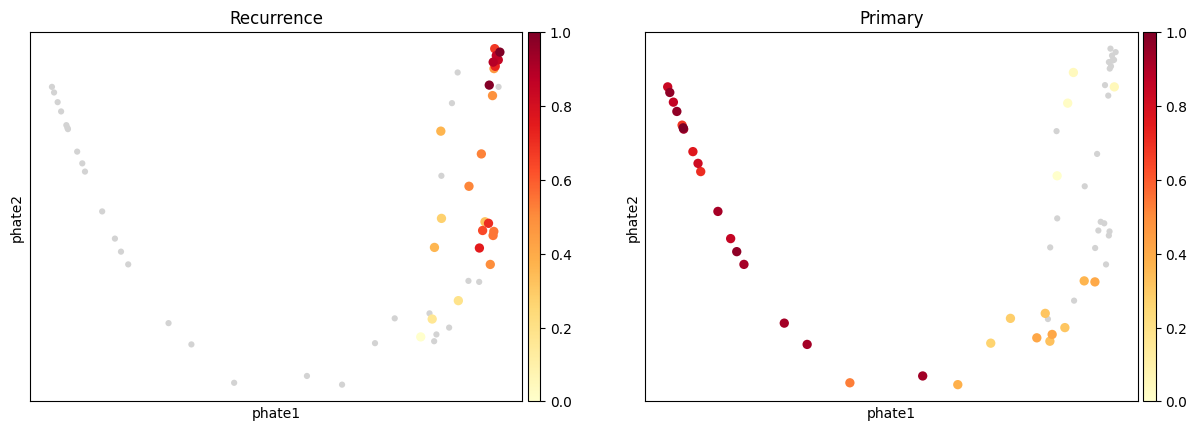

In [ ]:
# sc.tl.embedding_density(adata, groupby="Clinical_status")
sc.pl.embedding_density(adata, groupby="Clinical_status",basis='phate')

In [ ]:
import matplotlib.pyplot as plt

# Set default figure size globally
plt.rcParams["figure.figsize"] = (4.5, 2.5)

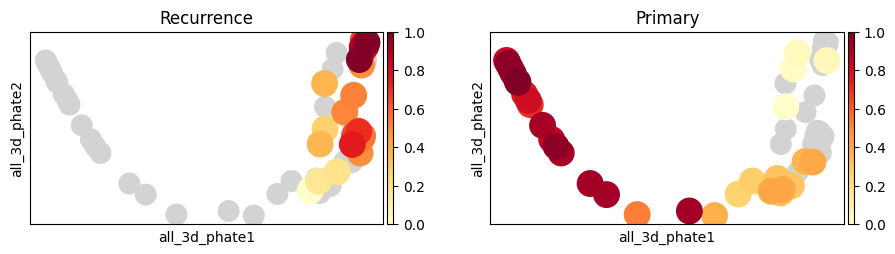

In [ ]:
import os
import scanpy as sc

# Define the path where the figure will be saved
save_path = "figures/umap_density_Clinical_status_figures"
file_name = "density_plot_beyond_DMG_only.pdf"

# Ensure the directory exists
os.makedirs(save_path, exist_ok=True)

# Save the plot
sc.pl.embedding_density(
    adata,
    groupby="Clinical_status",
    basis="all_3d_phate",
    bg_dotsize=1000, fg_dotsize=1500,
    save=os.path.join(file_name)
)